# Xi Stacked Bar Chart

Compare countries in a chosen benchmark year using a stacked bar chart split into `xi_dir`, `xi_amp_1`, and `xi_amp_2`.

- Set a `benchmark_year`
- Choose `selected_countries` or switch `include_all_countries = True`
- Toggle `normalize_to_share` for a 100% stacked view
- Toggle `sort_by_amp2_share` to sort by `xi_amp_2 / xi` instead of total `xi`

In [70]:
from pathlib import Path
import os
import sys
import importlib

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(project_root)
src_path = str(project_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from io_networks.config import load_config
import io_networks.viz_xi as viz_xi
importlib.reload(viz_xi)

load_xi_data = viz_xi.load_xi_data

In [71]:
cfg = load_config('config/default.yaml')
variant = None  # None -> inferred from config
benchmark_year = 2017
selected_countries = ['USA', 'CHN', 'DEU', 'JPN', 'GBR', 'IND', 'BRA', 'PER', 'AGO']
include_all_countries = False
normalize_to_share = True  # False -> levels, True -> 100% stacked bars
sort_by_amp2_share = True  # False -> sort by total xi, True -> sort by xi_amp_2 / xi
only_ok = True
top_n = None  # set an integer to keep only the top N countries after sorting

component_cols = ['xi_dir', 'xi_amp_1', 'xi_amp_2']
component_labels = {
    'xi_dir': r'$\xi_{dir}$',
    'xi_amp_1': r'$\xi_{near}$',
    'xi_amp_2': r'$\xi_{deep}$',
}
component_colors = {
    'xi_dir': '#3f4348',
    'xi_amp_1': '#8eb8e5',
    'xi_amp_2': '#c97a3d',
}

In [72]:
df = load_xi_data(cfg=cfg, variant=variant).copy()
df['country'] = df['country'].astype(str).str.upper()
df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')

for col in ['xi', *component_cols]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

if only_ok and 'status' in df.columns:
    df = df[df['status'] == 'ok'].copy()

available_years = sorted(int(y) for y in df['year'].dropna().unique())
available_countries = sorted(df.loc[df['year'] == benchmark_year, 'country'].dropna().unique().tolist())

if benchmark_year not in available_years:
    raise ValueError(f'benchmark_year={benchmark_year} is not available. Valid years: {available_years}')

if include_all_countries:
    countries_to_use = available_countries
else:
    countries_to_use = [str(c).upper() for c in selected_countries]

plot_df = df[(df['year'] == benchmark_year) & (df['country'].isin(countries_to_use))].copy()
plot_df = plot_df.dropna(subset=['country', 'xi', *component_cols]).copy()

if plot_df.empty:
    raise ValueError('No rows remain after applying the benchmark year and country filters.')

plot_df['xi_total_from_components'] = plot_df[component_cols].sum(axis=1)
plot_df['xi_amp_2_share'] = plot_df['xi_amp_2'] / plot_df['xi_total_from_components'].replace(0.0, pd.NA)

sort_col = 'xi_amp_2_share' if sort_by_amp2_share else 'xi_total_from_components'
plot_df = plot_df.sort_values(sort_col, ascending=False, kind='mergesort').reset_index(drop=True)

if top_n is not None:
    plot_df = plot_df.head(int(top_n)).copy()

display_cols = ['country', 'year', 'xi', 'xi_total_from_components', 'xi_amp_2_share', *component_cols]
print(f'rows plotted: {len(plot_df)}')
print(f'benchmark year: {benchmark_year}')
print(f'include all countries: {include_all_countries}')
print(f'sorted by: {sort_col}')
plot_df[display_cols].head(15)

rows plotted: 9
benchmark year: 2017
include all countries: False
sorted by: xi_amp_2_share


,country,year,xi,xi_total_from_components,xi_amp_2_share,xi_dir,xi_amp_1,xi_amp_2
0,CHN,2017,0.040896,0.040896,0.710141,0.004224,0.007630,0.029042
1,GBR,2017,0.022386,0.022386,0.588567,0.000623,0.008587,0.013176
2,DEU,2017,0.025341,0.025341,0.494967,0.004285,0.008513,0.012543
3,PER,2017,0.045244,0.045244,0.361389,0.008255,0.020639,0.016351
4,BRA,2017,0.056171,0.056171,0.338829,0.022665,0.014474,0.019032
5,IND,2017,0.062371,0.062371,0.330480,0.023169,0.018590,0.020613
6,JPN,2017,0.052224,0.052224,0.330065,0.020413,0.014574,0.017237
7,USA,2017,0.032165,0.032165,0.303852,0.013700,0.008691,0.009773
8,AGO,2017,0.145015,0.145015,0.157513,0.056274,0.065899,0.022842


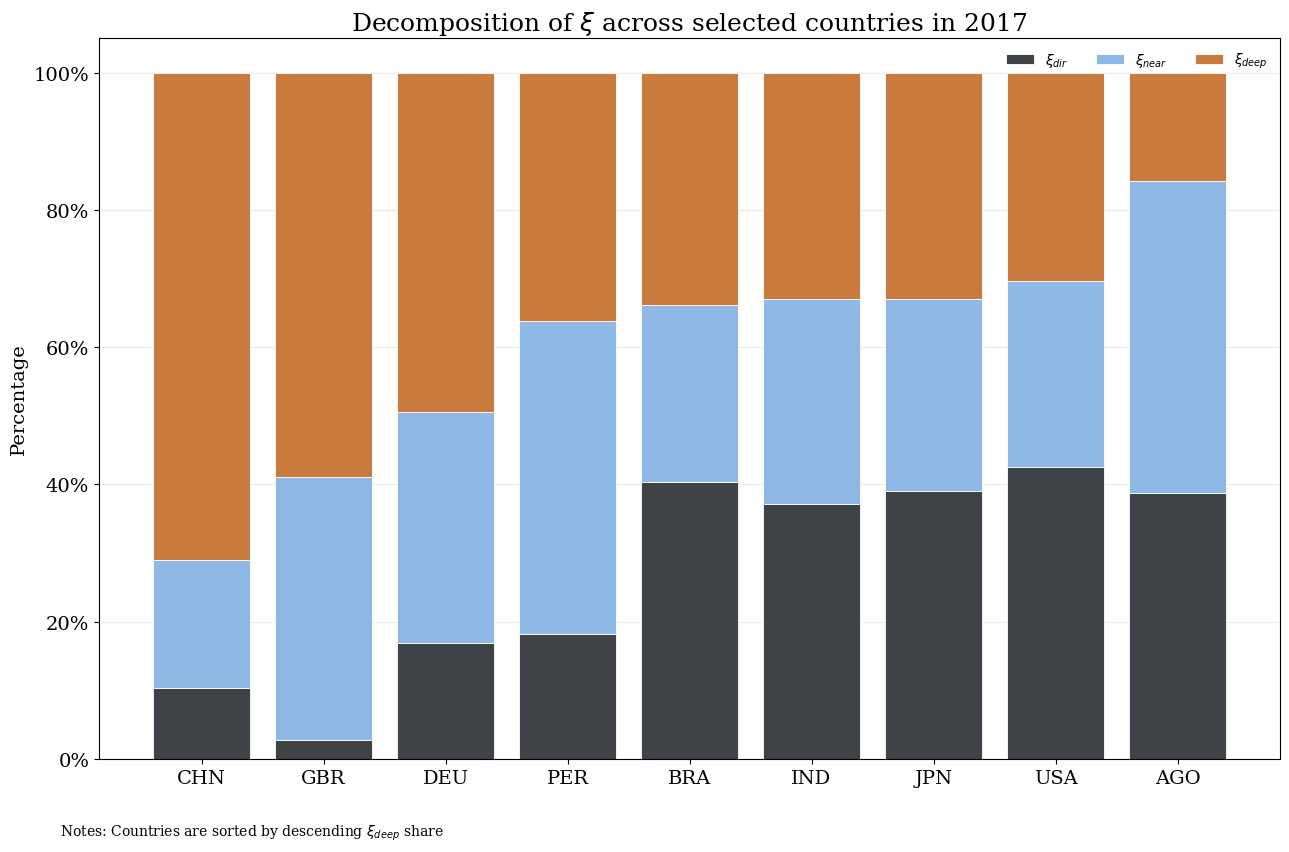

In [80]:
plot_values = plot_df[['country', *component_cols, 'xi_total_from_components', 'xi_amp_2_share']].copy()

if normalize_to_share:
    denom = plot_values['xi_total_from_components'].replace(0.0, pd.NA)
    for col in component_cols:
        plot_values[col] = plot_values[col] / denom

fig_width = max(13, 0.55 * len(plot_values) + 4)
fig, ax = plt.subplots(figsize=(fig_width, 8.5))

bottom = pd.Series(0.0, index=plot_values.index)
for col in component_cols:
    ax.bar(
        plot_values['country'],
        plot_values[col],
        bottom=bottom,
        label=component_labels[col],
        color=component_colors[col],
        edgecolor='white',
        linewidth=0.6,
    )
    bottom = bottom + plot_values[col].fillna(0.0)

if normalize_to_share:
    ax.set_ylabel(r'Share of total $\xi$', fontfamily='serif')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    title_mode = '100% stacked'
else:
    ax.set_ylabel(r'$\xi$', fontfamily='serif')
    title_mode = 'stacked levels'

sort_label = r'$\xi_{amp,2} / \xi$' if sort_by_amp2_share else r'total $\xi$'
title_scope = 'all countries' if include_all_countries else 'selected countries'
ax.set_title(
    rf'Decomposition of $\xi$ across selected countries in {benchmark_year}',
    fontfamily='serif', fontsize=18,
)
ax.grid(axis='y', alpha=0.25, linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False, ncol=3)
plt.xticks(rotation=0, ha='center')

for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontfamily('serif')
    tick.set_fontsize(14)

fig.text(
    0.05, 0.01,
    r'Notes: Countries are sorted by descending $\xi_{deep}$ share',
    ha='left',
    fontsize=10,
    color='black',
    fontfamily='serif',
)

ax.set_ylabel(rf"Percentage", fontfamily='serif', fontsize=14)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

## Try Different Inputs

- Change `benchmark_year` to any year available in `xi_by_country_year.parquet`
- Edit `selected_countries` or set `include_all_countries = True`
- Switch `normalize_to_share = True` for a 100% stacked chart
- Switch `sort_by_amp2_share = True` to sort by `xi_amp_2 / xi`
- Set `top_n` if you want to limit the chart after sorting